## 1. Setup and imports
### 1.1 Experiment setup

This notebook evaluates a minimal two-client collaborative learning simulation under multiple random seeds.

#### Experimental design
- A shared held-out test set is created first.
- The remaining training data is split into two clients.
- Each client receives its own local data stream split into 3 sequential batches.
- Three strategies are compared:
  - `local_only`
  - `full_transfer`
  - `output_layer_only`
- Performance is evaluated on the shared test set after each collaborative round.
- Final-round results are aggregated across seeds to assess robustness.
- Communication cost is approximated using the number of transferred trainable parameters.

#### Goal of this notebook
The goal is not to prove that one strategy is universally best, but to test whether the performance pattern observed in a single run remains stable across multiple random seeds.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import typing_extensions
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy

# Global experiment settings
N_ROUNDS = 3
EPOCHS = 20
LR = 0.01
TEST_SIZE = 0.2

SEEDS = [37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]

def set_all_seeds(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## 2. Load and preprocess data

In [2]:
file_path = "../data/data.csv"
df = pd.read_csv(file_path)

print(df.shape)
df.head()

(944, 10)


,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


In [3]:
print(df.columns.tolist())
print(df.dtypes)
print(df.isna().sum())
target_col = "fail"
print(df[target_col].value_counts())

['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
footfall       int64
tempMode       int64
AQ             int64
USS            int64
CS             int64
VOC            int64
RP             int64
IP             int64
Temperature    int64
fail           int64
dtype: object
footfall       0
tempMode       0
AQ             0
USS            0
CS             0
VOC            0
RP             0
IP             0
Temperature    0
fail           0
dtype: int64
fail
0    551
1    393
Name: count, dtype: int64


In [4]:
df_model = df.copy()

# Drop non-feature columns (optional but may be useful for other datasets)
drop_cols = []
for col in df_model.columns:
    if "id" in col.lower():
        drop_cols.append(col)

if drop_cols:
    df_model = df_model.drop(columns=drop_cols)

# Encode binary target if needed
if df_model[target_col].dtype == "object":
    unique_vals = df_model[target_col].unique()
    print("Target values:", unique_vals)
    df_model[target_col] = df_model[target_col].astype("category").cat.codes

df_model.head()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


In [5]:
print(df_model[target_col].value_counts())
X = df_model.drop(columns=[target_col])
y = df_model[target_col]
print("X shape:", X.shape)
print("y shape:", y.shape)

fail
0    551
1    393
Name: count, dtype: int64
X shape: (944, 9)
y shape: (944,)


## 3. Seed-aware data preparation

In [6]:
def prepare_collaborative_data(X, y, seed=42, test_size=0.2, n_rounds=3):
    # Shared test set
    X_train_pool, X_test_shared, y_train_pool, y_test_shared = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=seed
    )

    # Split remaining training pool into two clients
    X_client1, X_client2, y_client1, y_client2 = train_test_split(
        X_train_pool, y_train_pool,
        test_size=0.5,
        stratify=y_train_pool,
        random_state=seed
    )

    client1_batches = split_into_sequential_batches(
        X_client1.reset_index(drop=True),
        y_client1.reset_index(drop=True),
        n_batches=n_rounds
    )

    client2_batches = split_into_sequential_batches(
        X_client2.reset_index(drop=True),
        y_client2.reset_index(drop=True),
        n_batches=n_rounds
    )

    return {
        "X_train_pool": X_train_pool,
        "X_test_shared": X_test_shared,
        "y_test_shared": y_test_shared,
        "client1_batches": client1_batches,
        "client2_batches": client2_batches,
        "X_client1": X_client1,
        "X_client2": X_client2,
        "y_client1": y_client1,
        "y_client2": y_client2,
    }

def split_into_sequential_batches(X_df, y_series, n_batches=3):
    batch_size = len(X_df) // n_batches
    batches = []

    for i in range(n_batches):
        start = i * batch_size
        end = (i + 1) * batch_size if i < n_batches - 1 else len(X_df)

        X_batch = X_df.iloc[start:end].copy()
        y_batch = y_series.iloc[start:end].copy()

        batches.append((X_batch, y_batch))

    return batches

In [7]:
# One example split preview using a single seed
prepared = prepare_collaborative_data(X, y, seed=42, test_size=TEST_SIZE, n_rounds=N_ROUNDS)

print("Shared test set:", prepared["X_test_shared"].shape, prepared["y_test_shared"].shape)
print("Client 1 size:", prepared["X_client1"].shape, prepared["y_client1"].shape)
print("Client 2 size:", prepared["X_client2"].shape, prepared["y_client2"].shape)

Shared test set: (189, 9) (189,)
Client 1 size: (377, 9) (377,)
Client 2 size: (378, 9) (378,)


## 4. MLP model

In [8]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.hidden = nn.Linear(input_dim, 16)
        self.relu = nn.ReLU()
        self.output = nn.Linear(16, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

## 5. Helper functions
### 5.1 Scaling and tensor conversion

In [9]:
def fit_scaler_on_train_pool(X_train_pool):
    scaler = StandardScaler()
    scaler.fit(X_train_pool)
    return scaler


def to_tensor_dataset(X_df, y_series, scaler):
    X_scaled = scaler.transform(X_df)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_series.values.reshape(-1, 1), dtype=torch.float32)
    return TensorDataset(X_tensor, y_tensor)

### 5.2 Local training and evaluation

In [10]:
def train_one_batch(model, X_batch, y_batch, scaler, epochs=20, lr=0.01, batch_size=32, seed=42):
    model.train()

    dataset = to_tensor_dataset(X_batch, y_batch, scaler)

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=generator)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        for Xb, yb in loader:
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()


def evaluate_model(model, X_eval, y_eval, scaler):
    model.eval()

    X_scaled = scaler.transform(X_eval)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        preds = (probs >= 0.5).astype(int)

    y_true = y_eval.values

    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }

### 5.3 Transfer / averaging helpers

In [11]:
def average_full_models(model_a, model_b):
    new_model = deepcopy(model_a)
    state_a = model_a.state_dict()
    state_b = model_b.state_dict()

    averaged_state = {}
    for key in state_a:
        averaged_state[key] = (state_a[key] + state_b[key]) / 2.0

    new_model.load_state_dict(averaged_state)
    return new_model


def average_output_layer_only(model_a, model_b):
    new_model_a = deepcopy(model_a)
    new_model_b = deepcopy(model_b)

    with torch.no_grad():
        avg_weight = (model_a.output.weight.data + model_b.output.weight.data) / 2.0
        avg_bias = (model_a.output.bias.data + model_b.output.bias.data) / 2.0

        new_model_a.output.weight.data.copy_(avg_weight)
        new_model_a.output.bias.data.copy_(avg_bias)

        new_model_b.output.weight.data.copy_(avg_weight)
        new_model_b.output.bias.data.copy_(avg_bias)

    return new_model_a, new_model_b

### 5.4 Parameter count helpers

In [12]:
def count_total_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_output_layer_params(model):
    return sum(p.numel() for p in model.output.parameters() if p.requires_grad)

### 5.5 Experiment runner

In [13]:
def run_collaborative_experiment(
    mode,
    client1_batches,
    client2_batches,
    X_test_shared,
    y_test_shared,
    X_train_pool,
    input_dim,
    seed=42,
    epochs=20,
    lr=0.01
):
    set_all_seeds(seed)

    scaler = fit_scaler_on_train_pool(X_train_pool)

    base_model = SimpleMLP(input_dim)
    client1_model = deepcopy(base_model)
    client2_model = deepcopy(base_model)

    results = []

    total_params = count_total_params(base_model)
    output_params = count_output_layer_params(base_model)

    cumulative_transfer_cost = 0

    for round_idx, ((Xb1, yb1), (Xb2, yb2)) in enumerate(zip(client1_batches, client2_batches), start=1):
        # local updates
        train_one_batch(client1_model, Xb1, yb1, scaler, epochs=epochs, lr=lr, seed=seed + round_idx * 10 + 1)
        train_one_batch(client2_model, Xb2, yb2, scaler, epochs=epochs, lr=lr, seed=seed + round_idx * 10 + 2)

        # transfer step
        if mode == "full_transfer":
            averaged_model = average_full_models(client1_model, client2_model)
            client1_model = deepcopy(averaged_model)
            client2_model = deepcopy(averaged_model)
            cumulative_transfer_cost += total_params * 2

        elif mode == "output_layer_only":
            client1_model, client2_model = average_output_layer_only(client1_model, client2_model)
            cumulative_transfer_cost += output_params * 2

        elif mode == "local_only":
            pass

        else:
            raise ValueError(f"Unknown mode: {mode}")

        metrics = evaluate_model(client1_model, X_test_shared, y_test_shared, scaler)

        results.append({
            "seed": seed,
            "mode": mode,
            "round": round_idx,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "cumulative_transfer_cost": cumulative_transfer_cost
        })

    return pd.DataFrame(results)

In [14]:
def run_all_modes_for_seed(X, y, seed=42, n_rounds=3, epochs=20, lr=0.01, test_size=0.2):
    prepared = prepare_collaborative_data(X, y, seed=seed, test_size=test_size, n_rounds=n_rounds)
    input_dim = X.shape[1]

    results_local = run_collaborative_experiment(
        mode="local_only",
        client1_batches=prepared["client1_batches"],
        client2_batches=prepared["client2_batches"],
        X_test_shared=prepared["X_test_shared"],
        y_test_shared=prepared["y_test_shared"],
        X_train_pool=prepared["X_train_pool"],
        input_dim=input_dim,
        seed=seed,
        epochs=epochs,
        lr=lr
    )

    results_full = run_collaborative_experiment(
        mode="full_transfer",
        client1_batches=prepared["client1_batches"],
        client2_batches=prepared["client2_batches"],
        X_test_shared=prepared["X_test_shared"],
        y_test_shared=prepared["y_test_shared"],
        X_train_pool=prepared["X_train_pool"],
        input_dim=input_dim,
        seed=seed,
        epochs=epochs,
        lr=lr
    )

    results_partial = run_collaborative_experiment(
        mode="output_layer_only",
        client1_batches=prepared["client1_batches"],
        client2_batches=prepared["client2_batches"],
        X_test_shared=prepared["X_test_shared"],
        y_test_shared=prepared["y_test_shared"],
        X_train_pool=prepared["X_train_pool"],
        input_dim=input_dim,
        seed=seed,
        epochs=epochs,
        lr=lr
    )

    return pd.concat([results_local, results_full, results_partial], ignore_index=True)

## 6. Multi-seed experiment loop

In [15]:
multi_seed_results = []

for seed in SEEDS:
    seed_results = run_all_modes_for_seed(
        X, y,
        seed=seed,
        n_rounds=N_ROUNDS,
        epochs=EPOCHS,
        lr=LR,
        test_size=TEST_SIZE
    )
    multi_seed_results.append(seed_results)

all_results_df = pd.concat(multi_seed_results, ignore_index=True)
all_results_df.head()

,seed,mode,round,accuracy,precision,recall,f1,cumulative_transfer_cost
0,37,local_only,1,0.920635,0.900000,0.911392,0.905660,0
1,37,local_only,2,0.867725,0.787234,0.936709,0.855491,0
2,37,local_only,3,0.878307,0.825581,0.898734,0.860606,0
3,37,full_transfer,1,0.925926,0.882353,0.949367,0.914634,354
4,37,full_transfer,2,0.915344,0.888889,0.911392,0.900000,708


## 7. Results table

In [16]:
final_results_df = (
    all_results_df
    .sort_values(["seed", "mode", "round"])
    .groupby(["seed", "mode"], as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

final_results_df

,seed,mode,round,accuracy,precision,recall,f1,cumulative_transfer_cost
0,37,full_transfer,3,0.899471,0.857143,0.911392,0.883436,1062
1,37,local_only,3,0.878307,0.825581,0.898734,0.860606,0
2,37,output_layer_only,3,0.873016,0.808989,0.911392,0.857143,102
3,38,full_transfer,3,0.915344,0.920000,0.873418,0.896104,1062
4,38,local_only,3,0.925926,0.911392,0.911392,0.911392,0
5,38,output_layer_only,3,0.915344,0.888889,0.911392,0.900000,102
6,39,full_transfer,3,0.857143,0.817073,0.848101,0.832298,1062
7,39,local_only,3,0.862434,0.811765,0.873418,0.841463,0
8,39,output_layer_only,3,0.851852,0.800000,0.860759,0.829268,102
9,40,full_transfer,3,0.873016,0.839506,0.860759,0.850000,1062


In [17]:
summary_df = (
    final_results_df
    .groupby("mode", as_index=False)
    .agg(
        mean_final_accuracy=("accuracy", "mean"),
        mean_final_precision=("precision", "mean"),
        mean_final_recall=("recall", "mean"),
        mean_final_f1=("f1", "mean"),
        std_final_f1=("f1", "std"),
        min_final_f1=("f1", "min"),
        max_final_f1=("f1", "max"),
        mean_transfer_cost=("cumulative_transfer_cost", "mean")
    )
    .sort_values("mean_final_f1", ascending=False)
)

summary_df

,mode,mean_final_accuracy,mean_final_precision,mean_final_recall,mean_final_f1,std_final_f1,min_final_f1,max_final_f1,mean_transfer_cost
0,full_transfer,0.899952,0.880332,0.881473,0.880533,0.024334,0.832298,0.911392,1062.0
1,local_only,0.895623,0.880758,0.869965,0.874195,0.027759,0.813793,0.911392,0.0
2,output_layer_only,0.892256,0.867347,0.878021,0.872001,0.025967,0.823529,0.900000,102.0


## 8. Final F1 across seeds
Communication cost is not plotted across seeds because, for a fixed model architecture and fixed number of collaborative rounds, transfer cost depends only on the transfer strategy and not on the random seed.

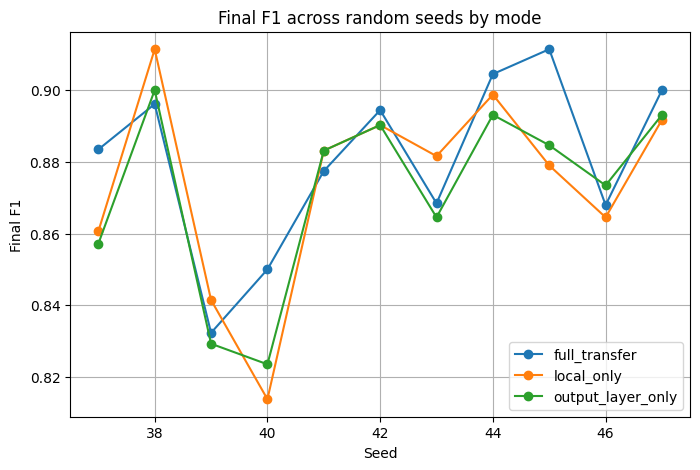

In [18]:
plt.figure(figsize=(8, 5))
for mode in final_results_df["mode"].unique():
    subset = final_results_df[final_results_df["mode"] == mode]
    plt.plot(subset["seed"], subset["f1"], marker="o", label=mode)

plt.xlabel("Seed")
plt.ylabel("Final F1")
plt.title("Final F1 across random seeds by mode")
plt.legend()
plt.grid(True)
plt.show()

## 9. Short interpretation

Across multiple random seeds, `full_transfer` achieved the highest mean final F1, but its advantage over `local_only` was small and not consistent across all runs. `output_layer_only` remained much cheaper in communication cost and sometimes matched or slightly exceeded `local_only`, but it did not show a stable advantage.

### Main takeaways
- `full_transfer` shows the strongest average performance in this small two-client setup.
- The performance gap between strategies is small and sensitive to random seed.
- `output_layer_only` is a reasonable low-cost baseline, but not a consistently superior one.
- The current experiment is too small and noisy to support a strong ranking claim.
- The clearest robust result is the tradeoff between communication cost and predictive performance.

In [19]:
all_results_df.to_csv("../results/two_client_seed_validation_all_rounds.csv", index=False)
final_results_df.to_csv("../results/two_client_seed_validation_final_results.csv", index=False)
summary_df.to_csv("../results/two_client_seed_validation_summary.csv", index=False)

print("Saved seed-validation results to ../results/")

Saved seed-validation results to ../results/
